<a href="https://colab.research.google.com/github/JoshPeralta0418/ImageClassifier-App/blob/main/notebooks/train-yolo11-object-detection-on-custom-dataset%20v5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Roboflow Notebooks](https://media.roboflow.com/notebooks/template/bannertest2-2.png?ik-sdk-version=javascript-1.4.3&updatedAt=1672932710194)](https://github.com/roboflow/notebooks)

# How to Train YOLO11 Object Detection on a Custom Dataset

---

[![GitHub](https://badges.aleen42.com/src/github.svg)](https://github.com/ultralytics/ultralytics)

YOLO11 builds on the advancements introduced in YOLOv9 and YOLOv10 earlier this year, incorporating improved architectural designs, enhanced feature extraction techniques, and optimized training methods.

YOLO11m achieves a higher mean mAP score on the COCO dataset while using 22% fewer parameters than YOLOv8m, making it computationally lighter without sacrificing performance.

YOLOv11 is available in 5 different sizes, ranging from `2.6M` to `56.9M` parameters, and capable of achieving from `39.5` to `54.7` mAP on the COCO dataset.

## Setup

### Configure API keys

To fine-tune YOLO11, you need to provide your Roboflow API key. Follow these steps:

- Go to your [`Roboflow Settings`](https://app.roboflow.com/settings/api) page. Click `Copy`. This will place your private key in the clipboard.
- In Colab, go to the left pane and click on `Secrets` (🔑). Store Roboflow API Key under the name `ROBOFLOW_API_KEY`.

### Before you start

Let's make sure that we have access to GPU. We can use `nvidia-smi` command to do that. In case of any problems navigate to `Edit` -> `Notebook settings` -> `Hardware accelerator`, set it to `GPU`, and then click `Save`.

In [1]:
!nvidia-smi

Fri May  2 09:16:50 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   58C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

**NOTE:** To make it easier for us to manage datasets, images and models we create a `HOME` constant.

In [2]:
import os
HOME = os.getcwd()
print(HOME)

/content


## Install YOLO11 via Ultralytics

In [3]:
%pip install "ultralytics<=8.3.40" supervision roboflow
import ultralytics
ultralytics.checks()

Ultralytics 8.3.40 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 41.4/112.6 GB disk)


## Inference with model pre-trained on COCO dataset

### CLI

**NOTE:** CLI requires no customization or Python code. You can simply run all tasks from the terminal with the yolo command.

In [4]:
!yolo task=detect mode=predict model=yolo11n.pt conf=0.25 source='https://media.roboflow.com/notebooks/examples/dog.jpeg' save=True

100% 5.35M/5.35M [00:00<00:00, 117MB/s]
Ultralytics 8.3.40 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 238 layers, 2,616,248 parameters, 0 gradients, 6.5 GFLOPs

100% 104k/104k [00:00<00:00, 100MB/s]
image 1/1 /content/dog.jpeg: 640x384 2 persons, 1 car, 1 dog, 1 handbag, 44.4ms
Speed: 14.9ms preprocess, 44.4ms inference, 315.1ms postprocess per image at shape (1, 3, 640, 384)
Results saved to runs/detect/predict
💡 Learn more at https://docs.ultralytics.com/modes/predict


**NOTE:** Result annotated image got saved in `{HOME}/runs/detect/predict/`. Let's display it.

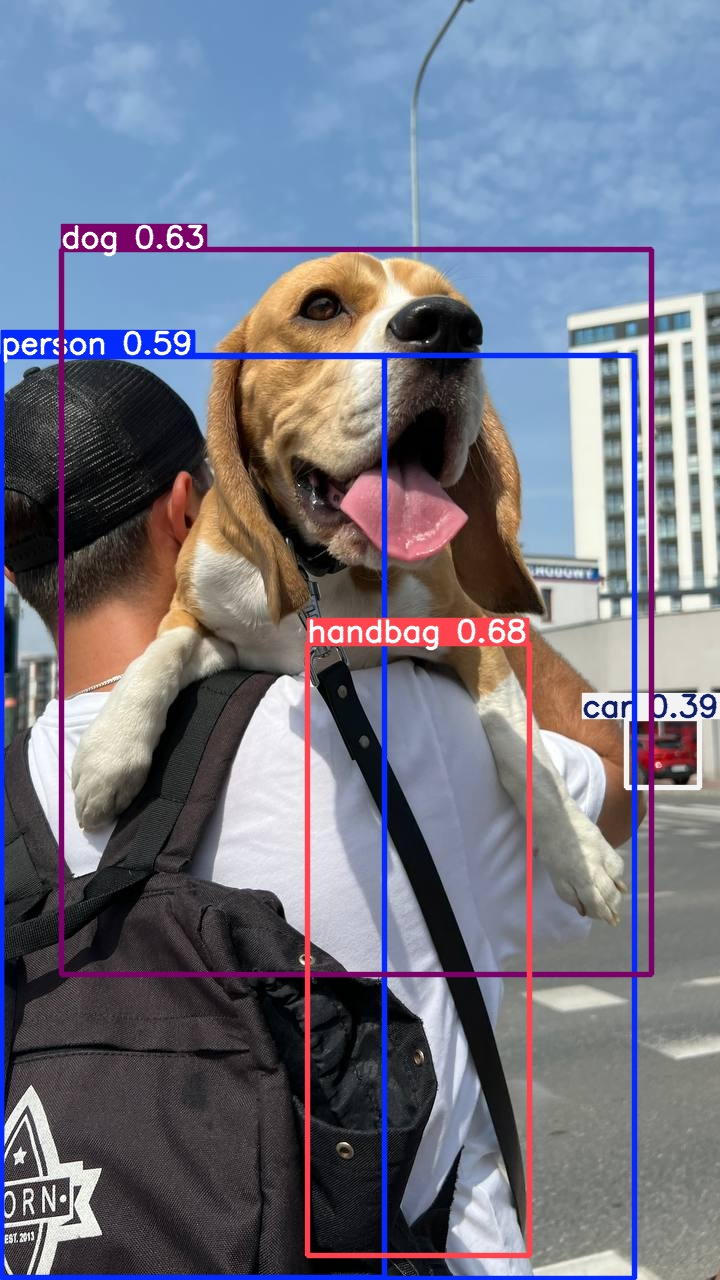

In [5]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/predict/dog.jpg', width=600)

### SDK

**NOTE:** YOLO's Python interface allows for seamless integration into your Python projects, making it easy to load, run, and process the model's output.

In [6]:
from ultralytics import YOLO
from PIL import Image
import requests

model = YOLO('yolo11n.pt')
image = Image.open(requests.get('https://media.roboflow.com/notebooks/examples/dog.jpeg', stream=True).raw)
result = model.predict(image, conf=0.25)[0]


0: 640x384 2 persons, 1 car, 1 dog, 1 handbag, 53.4ms
Speed: 3.5ms preprocess, 53.4ms inference, 157.2ms postprocess per image at shape (1, 3, 640, 384)


**NOTE:** The obtained `result` object stores information about the location, classes, and confidence levels of the detected objects.

In [7]:
result.boxes.xyxy

tensor([[3.0705e+02, 6.4341e+02, 5.2919e+02, 1.2558e+03],
        [6.1400e+01, 2.4994e+02, 6.5165e+02, 9.7412e+02],
        [1.7803e+00, 3.5551e+02, 6.3404e+02, 1.2788e+03],
        [1.1933e+00, 3.5620e+02, 3.8455e+02, 1.2776e+03],
        [6.2615e+02, 7.1818e+02, 6.9975e+02, 7.8754e+02]], device='cuda:0')

In [8]:
result.boxes.conf

tensor([0.6832, 0.6284, 0.5941, 0.3923, 0.3875], device='cuda:0')

In [9]:
result.boxes.cls

tensor([26., 16.,  0.,  0.,  2.], device='cuda:0')

**NOTE:** YOLO11 can be easily integrated with `supervision` using the familiar `from_ultralytics` connector.

In [10]:
import supervision as sv

detections = sv.Detections.from_ultralytics(result)

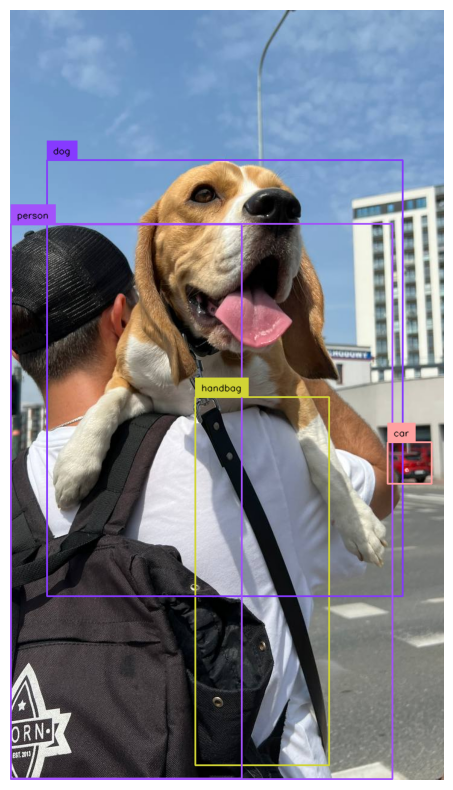

In [11]:
box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator(text_color=sv.Color.BLACK)

annotated_image = image.copy()
annotated_image = box_annotator.annotate(annotated_image, detections=detections)
annotated_image = label_annotator.annotate(annotated_image, detections=detections)

sv.plot_image(annotated_image, size=(10, 10))

## Fine-tune YOLO11 on custom dataset

**NOTE:** When training YOLOv11, make sure your data is located in `datasets`. If you'd like to change the default location of the data you want to use for fine-tuning, you can do so through Ultralytics' `settings.json`. In this tutorial, we will use one of the [datasets](https://universe.roboflow.com/liangdianzhong/-qvdww) available on [Roboflow Universe](https://universe.roboflow.com/). When downloading, make sure to select the `yolov11` export format.

In [12]:
!mkdir {HOME}/datasets
%cd {HOME}/datasets

from google.colab import userdata
from roboflow import Roboflow

# ROBOFLOW_API_KEY = userdata.get('ROBOFLOW_API_KEY')
ROBOFLOW_API_KEY = 'LUyk335leXSb5LPcrdzZ'
rf = Roboflow(api_key=ROBOFLOW_API_KEY)

workspace = rf.workspace("joshs-data-science-projects")
project = workspace.project("food-detection-rxmdl-boyoj")
version = project.version(5)
dataset = version.download("yolov11")

/content/datasets
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Food-Detection-5 in yolov11:: 100%|██████████| 6702/6702 [00:01<00:00, 4868.87it/s]


In [13]:
!pip install albumentations

## Create Synthetic Data and Augment underrepresented Classes

In [14]:
import os
from glob import glob
from collections import Counter
import random
import shutil

# ✅ Update these paths
FINAL_SPLIT_DIR = "/content/datasets/Food-Detection-5"
TRAIN_SPLIT_DIR = os.path.join(FINAL_SPLIT_DIR, "train")
AUG_IMAGE_DIR = os.path.join(FINAL_SPLIT_DIR, "augmented")

# Class ID to Name mapping (adjust as needed)
class_id_to_name = {
    0: "Chicken", 1: "GADC - Burger Steak", 2: "GADC - Cheeseburger", 3: "GADC - Cheeseburger TO",
    4: "GADC - Crispy Chicken Fillet Meal", 5: "GADC - Crispy Chicken Fillet Meal TO",
    6: "GADC - Crispy Chicken Sandwich", 7: "GADC - Crispy Chicken Sandwich TO",
    8: "GADC - Fries", 9: "GADC - McNuggets", 10: "GADC - McNuggets TO",
    11: "JFC - Burger Steak", 12: "JFC - Burger Steak TO", 13: "JFC - Cheesy Classic Jolly Hotdog",
    14: "JFC - Cheesy Classic Jolly Hotdog TO", 15: "JFC - Chickenjoy TO",
    16: "JFC - Jolly Crispy Fries", 17: "JFC - Jolly Spaghetti", 18: "JFC - Jolly Spaghetti - Pan",
    19: "JFC - Jolly Spaghetti TO"
}

def extract_classes_from_label(label_path):
    with open(label_path, "r") as f:
        lines = f.readlines()

    class_ids = []
    for line in lines:
        parts = line.strip().split()
        if len(parts) < 5:
            continue
        try:
            class_id = int(float(parts[0]))
            class_ids.append(class_id)
        except ValueError:
            print(f"⚠️ Invalid line in {label_path}: {line.strip()}")
    return class_ids

# Count training samples per class
train_label_dir = os.path.join(TRAIN_SPLIT_DIR, "labels")
train_labels = glob(os.path.join(train_label_dir, "*.txt"))
train_counts = Counter()

for lbl in train_labels:
    for cls in extract_classes_from_label(lbl):
        train_counts[cls] += 1

# Determine max number of samples among all classes
max_samples = max(train_counts.values())
print(f"📈 Max samples in training set: {max_samples}\n")

# Collect available augmented data
aug_label_files = glob(os.path.join(AUG_IMAGE_DIR, "*.txt"))
aug_class_map = {}

for lbl_path in aug_label_files:
    cls_ids = extract_classes_from_label(lbl_path)
    if len(set(cls_ids)) == 1:
        cls = cls_ids[0]
        if cls not in aug_class_map:
            aug_class_map[cls] = []
        aug_class_map[cls].append(lbl_path)

# Start augmentation for underrepresented classes
for cls_id in range(20):
    current_count = train_counts.get(cls_id, 0)
    name = class_id_to_name.get(cls_id, "Unknown")

    needed = max_samples - current_count
    if needed <= 0:
        continue

    print(f"🔄 Augmenting class {cls_id} ({name}): need {needed} more samples")

    # Get available augmented samples
    aug_lbls = aug_class_map.get(cls_id, [])
    if not aug_lbls:
        print(f"⚠️ No augmented data found for class {cls_id}")
        continue

    selected_aug = random.choices(aug_lbls, k=needed)

    for idx, aug_lbl_path in enumerate(selected_aug):
        base_name = os.path.splitext(os.path.basename(aug_lbl_path))[0]
        aug_img_path = os.path.join(AUG_IMAGE_DIR, base_name + ".jpg")
        new_base = f"{base_name}_aug{idx}"

        # New target paths in train dir
        new_img_path = os.path.join(TRAIN_SPLIT_DIR, "images", new_base + ".jpg")
        new_lbl_path = os.path.join(TRAIN_SPLIT_DIR, "labels", new_base + ".txt")

        # Copy image and label
        try:
            shutil.copy2(aug_img_path, new_img_path)
            shutil.copy2(aug_lbl_path, new_lbl_path)
        except Exception as e:
            print(f"❌ Error copying files for {base_name}: {e}")

# Final summary
print("\n📦 FINAL TRAINING SET SUMMARY")
header = f"{'Class ID':<9} | {'Class Name':<40} | {'Train':>6} | {'Needed':>6} | {'Final':>6}"
print(header)
print("-" * len(header))

for cls_id in range(20):
    name = class_id_to_name.get(cls_id, "Unknown")
    count = train_counts.get(cls_id, 0)
    needed = max_samples - count if count < max_samples else 0
    final = count + needed
    print(f"{cls_id:<9} | {name:<40} | {count:>6} | {needed:>6} | {final:>6}")


📈 Max samples in training set: 920

🔄 Augmenting class 1 (GADC - Burger Steak): need 662 more samples
⚠️ No augmented data found for class 1
🔄 Augmenting class 2 (GADC - Cheeseburger): need 790 more samples
⚠️ No augmented data found for class 2
🔄 Augmenting class 3 (GADC - Cheeseburger TO): need 714 more samples
⚠️ No augmented data found for class 3
🔄 Augmenting class 4 (GADC - Crispy Chicken Fillet Meal): need 596 more samples
⚠️ No augmented data found for class 4
🔄 Augmenting class 5 (GADC - Crispy Chicken Fillet Meal TO): need 872 more samples
⚠️ No augmented data found for class 5
🔄 Augmenting class 6 (GADC - Crispy Chicken Sandwich): need 850 more samples
⚠️ No augmented data found for class 6
🔄 Augmenting class 7 (GADC - Crispy Chicken Sandwich TO): need 846 more samples
⚠️ No augmented data found for class 7
🔄 Augmenting class 8 (GADC - Fries): need 406 more samples
⚠️ No augmented data found for class 8
🔄 Augmenting class 9 (GADC - McNuggets): need 762 more samples
⚠️ No aug

# Apply 70-20-10 split for Train, Validation and Test and ensure that multi-label classes have been considered

In [16]:
from collections import defaultdict
import math

# Ensure output dirs exist
VAL_SPLIT_DIR = os.path.join(FINAL_SPLIT_DIR, "val")
TEST_SPLIT_DIR = os.path.join(FINAL_SPLIT_DIR, "test")
for split_dir in [VAL_SPLIT_DIR, TEST_SPLIT_DIR]:
    os.makedirs(os.path.join(split_dir, "images"), exist_ok=True)
    os.makedirs(os.path.join(split_dir, "labels"), exist_ok=True)

# Step 1: Build image-to-classes and class-to-images maps
image_to_classes = {}
class_to_images = defaultdict(set)

image_paths = glob(os.path.join(TRAIN_SPLIT_DIR, "images", "*.jpg"))
label_dir = os.path.join(TRAIN_SPLIT_DIR, "labels")

for img_path in image_paths:
    base = os.path.splitext(os.path.basename(img_path))[0]
    lbl_path = os.path.join(label_dir, base + ".txt")

    if not os.path.exists(lbl_path):
        continue

    classes = extract_classes_from_label(lbl_path)
    if not classes:
        continue

    image_to_classes[img_path] = classes
    for cls in set(classes):  # Avoid duplicate entries
        class_to_images[cls].add(img_path)

# Step 2: Deduplicate images and shuffle
unique_images = list(image_to_classes.keys())
random.shuffle(unique_images)

# Step 3: Split based on image count (multi-label-aware, approximate)
total_images = len(unique_images)
train_count = int(total_images * 0.7)
val_count = int(total_images * 0.2)

train_set = set(unique_images[:train_count])
val_set = set(unique_images[train_count:train_count + val_count])
test_set = set(unique_images[train_count + val_count:])

def move_image_and_label(img_path, target_dir):
    base = os.path.splitext(os.path.basename(img_path))[0]
    lbl_path = os.path.join(TRAIN_SPLIT_DIR, "labels", base + ".txt")

    shutil.move(img_path, os.path.join(target_dir, "images", base + ".jpg"))
    shutil.move(lbl_path, os.path.join(target_dir, "labels", base + ".txt"))

# Step 4: Move files
for img in train_set:
    move_image_and_label(img, TRAIN_SPLIT_DIR)

for img in val_set:
    move_image_and_label(img, VAL_SPLIT_DIR)

for img in test_set:
    move_image_and_label(img, TEST_SPLIT_DIR)

# Step 5: Final Class Distribution Summary (Optional)
print("\n✅ Multi-label stratified split complete.")
print(f" - Train images: {len(train_set)}")
print(f" - Val images: {len(val_set)}")
print(f" - Test images: {len(test_set)}")

# Optional: Count per class per split
def count_classes_in_dir(label_folder):
    counts = Counter()
    for lbl_path in glob(os.path.join(label_folder, "*.txt")):
        classes = extract_classes_from_label(lbl_path)
        for cls in set(classes):
            counts[cls] += 1
    return counts

print("\n📊 Class distribution:")

cls_id_to_name = {
    0: "Chicken", 1: "GADC - Burger Steak", 2: "GADC - Cheeseburger", 3: "GADC - Cheeseburger TO",
    4: "GADC - Crispy Chicken Fillet Meal", 5: "GADC - Crispy Chicken Fillet Meal TO",
    6: "GADC - Crispy Chicken Sandwich", 7: "GADC - Crispy Chicken Sandwich TO",
    8: "GADC - Fries", 9: "GADC - McNuggets", 10: "GADC - McNuggets TO",
    11: "JFC - Burger Steak", 12: "JFC - Burger Steak TO", 13: "JFC - Cheesy Classic Jolly Hotdog",
    14: "JFC - Cheesy Classic Jolly Hotdog TO", 15: "JFC - Chickenjoy TO",
    16: "JFC - Jolly Crispy Fries", 17: "JFC - Jolly Spaghetti", 18: "JFC - Jolly Spaghetti - Pan",
    19: "JFC - Jolly Spaghetti TO"
}


for name, folder in [("Train", TRAIN_SPLIT_DIR), ("Val", VAL_SPLIT_DIR), ("Test", TEST_SPLIT_DIR)]:
    label_folder = os.path.join(folder, "labels")
    counts = count_classes_in_dir(label_folder)
    print(f"\n{name} set:")
    for cls_id, count in sorted(counts.items()):
        print(f" - {cls_id_to_name.get(cls_id, 'Unknown')}: {count}")



✅ Multi-label stratified split complete.
 - Train images: 1638
 - Val images: 468
 - Test images: 234

📊 Class distribution:

Train set:
 - Chicken: 298
 - GADC - Burger Steak: 119
 - GADC - Cheeseburger: 62
 - GADC - Cheeseburger TO: 104
 - GADC - Crispy Chicken Fillet Meal: 153
 - GADC - Crispy Chicken Fillet Meal TO: 25
 - GADC - Crispy Chicken Sandwich: 38
 - GADC - Crispy Chicken Sandwich TO: 31
 - GADC - Fries: 244
 - GADC - McNuggets: 75
 - GADC - McNuggets TO: 34
 - JFC - Burger Steak: 121
 - JFC - Burger Steak TO: 10
 - JFC - Cheesy Classic Jolly Hotdog: 78
 - JFC - Cheesy Classic Jolly Hotdog TO: 63
 - JFC - Chickenjoy TO: 49
 - JFC - Jolly Crispy Fries: 195
 - JFC - Jolly Spaghetti: 100
 - JFC - Jolly Spaghetti - Pan: 2
 - JFC - Jolly Spaghetti TO: 40

Val set:
 - Chicken: 210
 - GADC - Burger Steak: 90
 - GADC - Cheeseburger: 44
 - GADC - Cheeseburger TO: 71
 - GADC - Crispy Chicken Fillet Meal: 108
 - GADC - Crispy Chicken Fillet Meal TO: 18
 - GADC - Crispy Chicken Sandw

## Custom Training

In [21]:
%cd {HOME}

!yolo task=detect mode=train model=yolo11s.pt data={dataset.location}/data.yaml epochs=10 imgsz=640 plots=True

/content
New https://pypi.org/project/ultralytics/8.3.123 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.40 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolo11s.pt, data=/content/datasets/Food-Detection-5/data.yaml, epochs=10, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train3, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=N

**NOTE:** The results of the completed training are saved in `{HOME}/runs/detect/train/`. Let's examine them.

In [22]:
!ls {HOME}/runs/detect/train/

args.yaml  weights


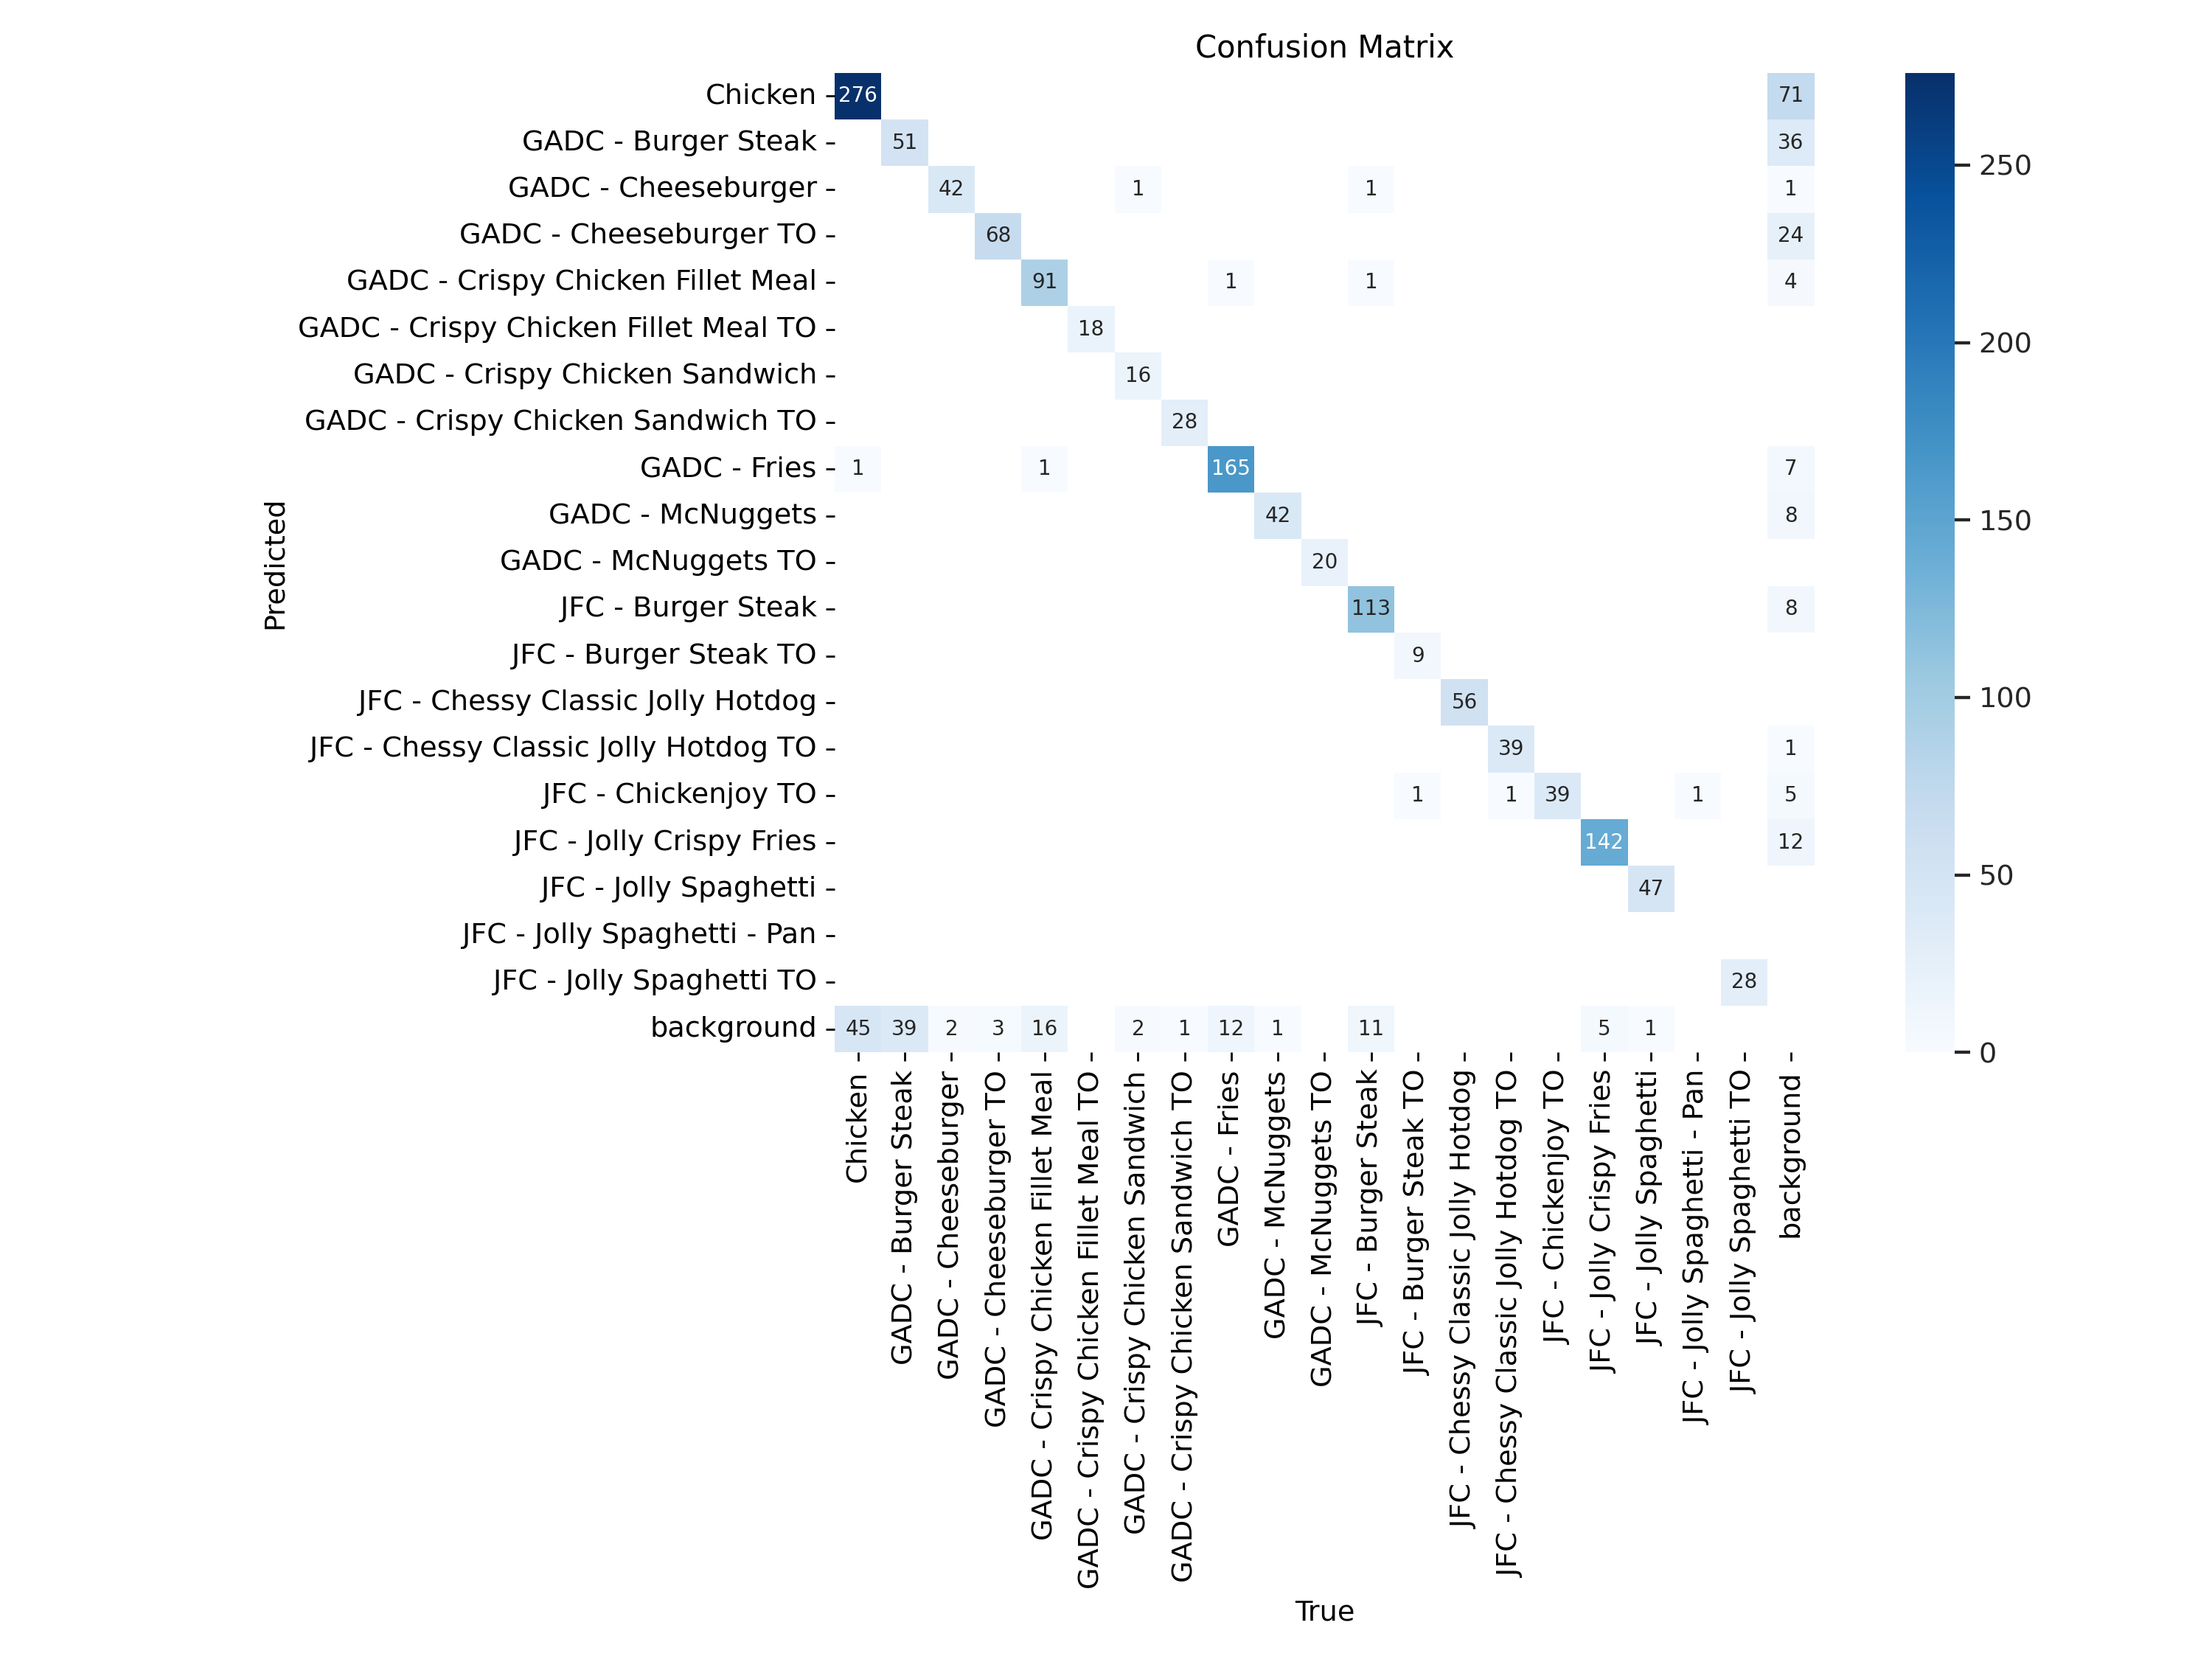

In [24]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train3/confusion_matrix.png', width=600)

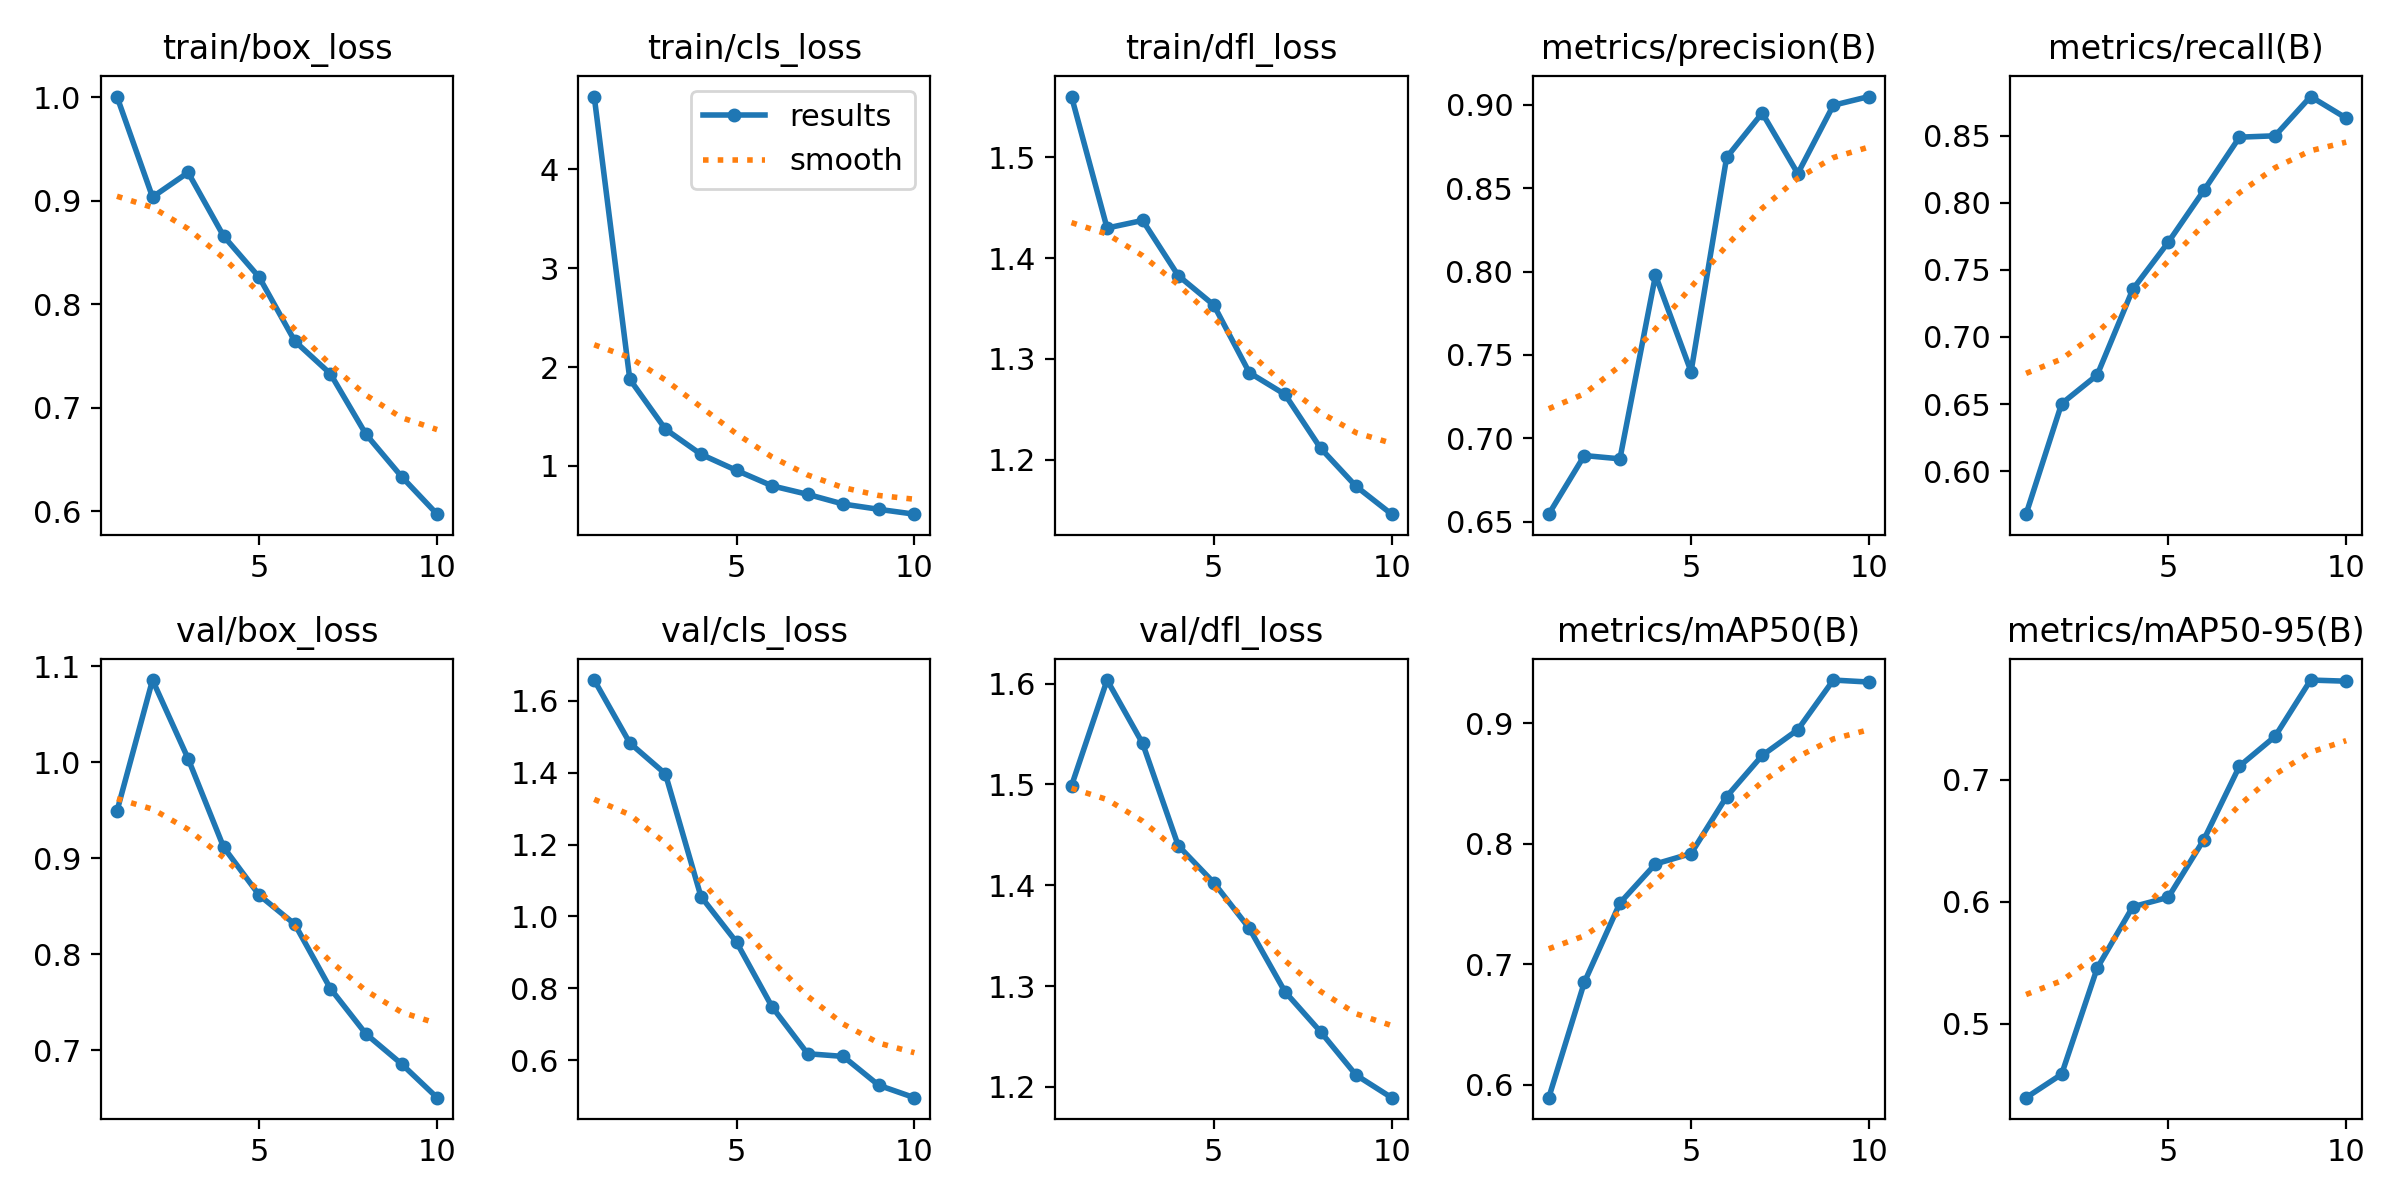

In [25]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train3/results.png', width=600)

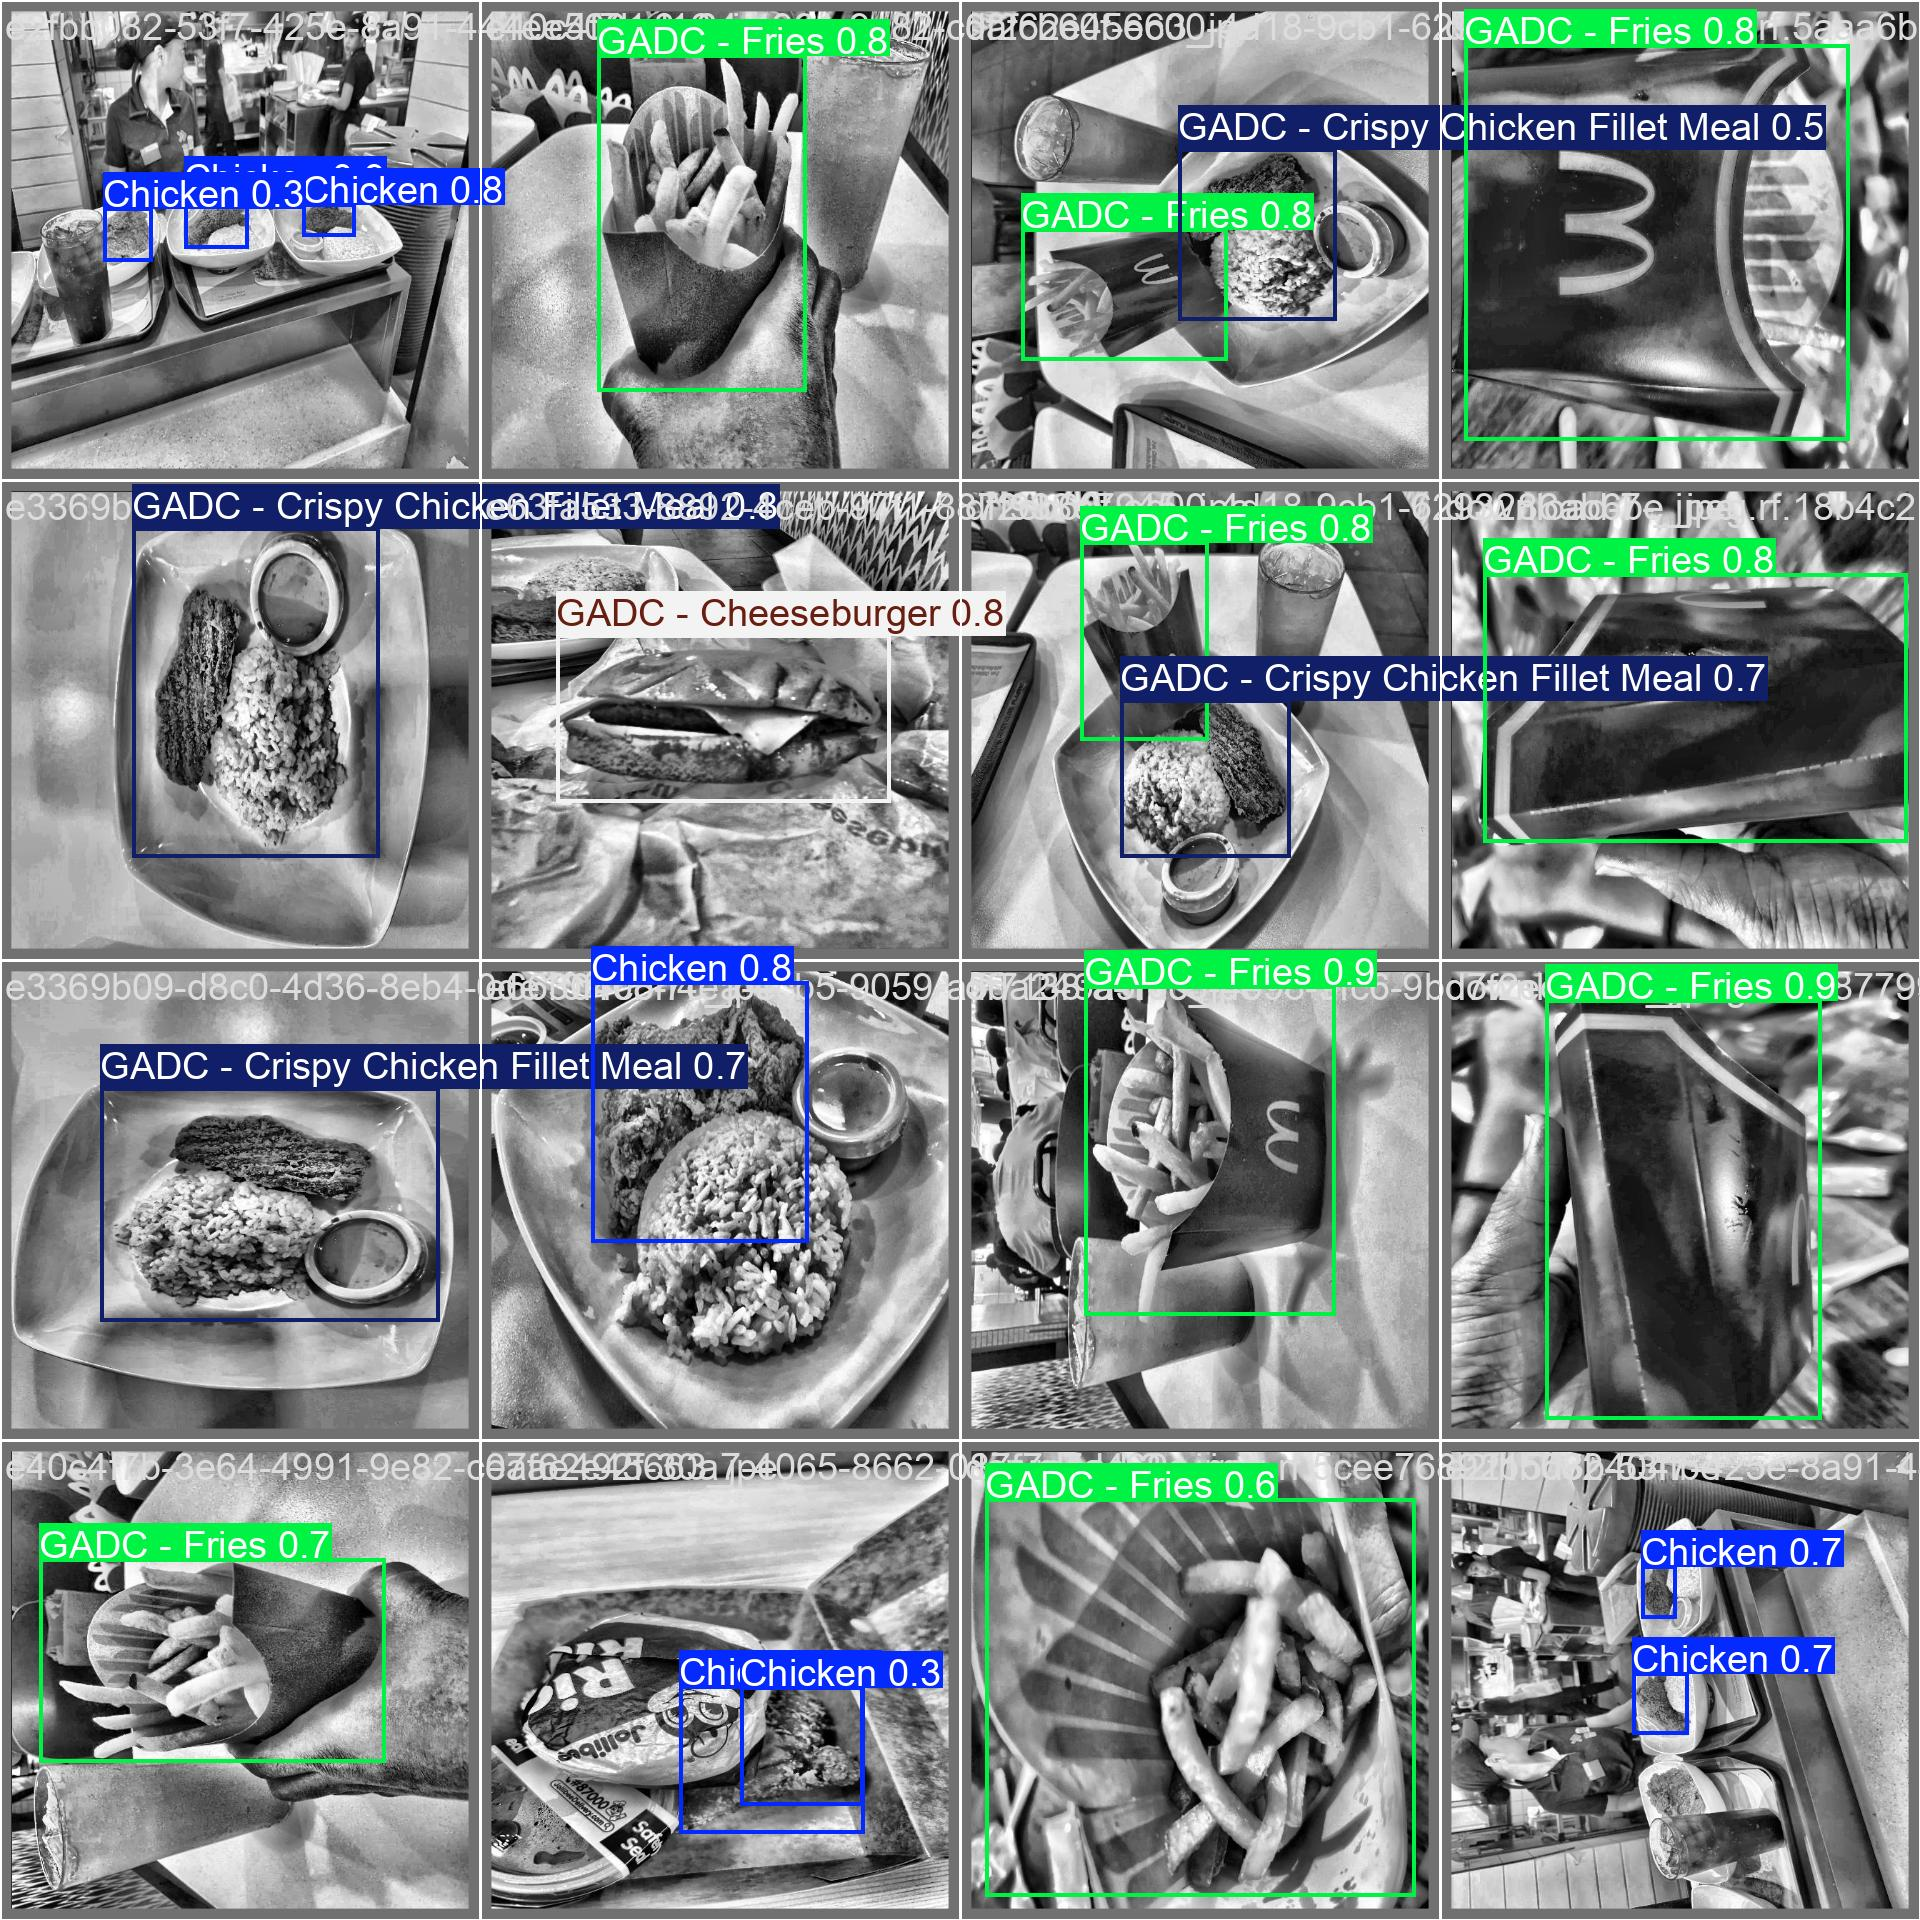

In [26]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train3/val_batch0_pred.jpg', width=600)

## Validate fine-tuned model

In [27]:
!yolo task=detect mode=val model={HOME}/runs/detect/train3/weights/best.pt data={dataset.location}/data.yaml

Ultralytics 8.3.40 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11s summary (fused): 238 layers, 9,420,540 parameters, 0 gradients, 21.3 GFLOPs
val: Scanning /content/datasets/Food-Detection-5/valid/labels.cache... 1136 images, 0 backgrounds, 0 corrupt: 100% 1136/1136 [00:00<?, ?it/s]
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 733, len(boxes) = 1437. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 71/71 [00:17<00:00,  4.14it/s]
                   all       1136       1437        0.9      0.879      0.936      0.782
               Chicken        210        322      0.727      0.848      0.838      0.691
   GADC - Burger Steak         90         90      0.564      0.567      0.531      0.419
   GADC - Cheeseburger    

## Inference with custom model

In [28]:
!yolo task=detect mode=predict model={HOME}/runs/detect/train3/weights/best.pt conf=0.25 source={dataset.location}/test/images save=True

Ultralytics 8.3.40 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11s summary (fused): 238 layers, 9,420,540 parameters, 0 gradients, 21.3 GFLOPs

image 1/570 /content/datasets/Food-Detection-5/test/images/0448654b-5366-4732-aab2-6376ba310c5a_jpeg.rf.fe7013b28c118759c9c85d0a8d84e867.jpg: 640x640 1 GADC - Fries, 15.7ms
image 2/570 /content/datasets/Food-Detection-5/test/images/0787f643-bdd8-4ae4-882d-03db32e2e7f7_jpeg.rf.31f82d7f3114561d35dcad044c39c2fd.jpg: 640x640 1 GADC - Crispy Chicken Fillet Meal, 15.7ms
image 3/570 /content/datasets/Food-Detection-5/test/images/0b45d9b1-a689-40e5-ada2-50f0c512b914_jpeg.rf.5d275692a72340d46edb9777e5ab57ea.jpg: 640x640 1 GADC - Fries, 15.7ms
image 4/570 /content/datasets/Food-Detection-5/test/images/0c997113-2447-41f8-806e-6af2c70815e6_jpeg.rf.8b1d1ce72c3c5f9f18e3decf94a035c2.jpg: 640x640 1 GADC - Crispy Chicken Fillet Meal, 1 GADC - Fries, 15.6ms
image 5/570 /content/datasets/Food-Detection-5/test/images/0cf559ff-1e3f-4efc-bcb7-

**NOTE:** Let's take a look at few results.

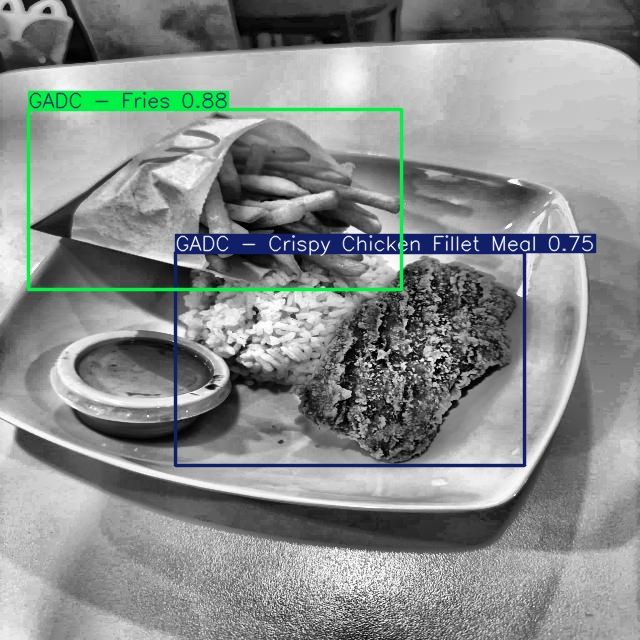

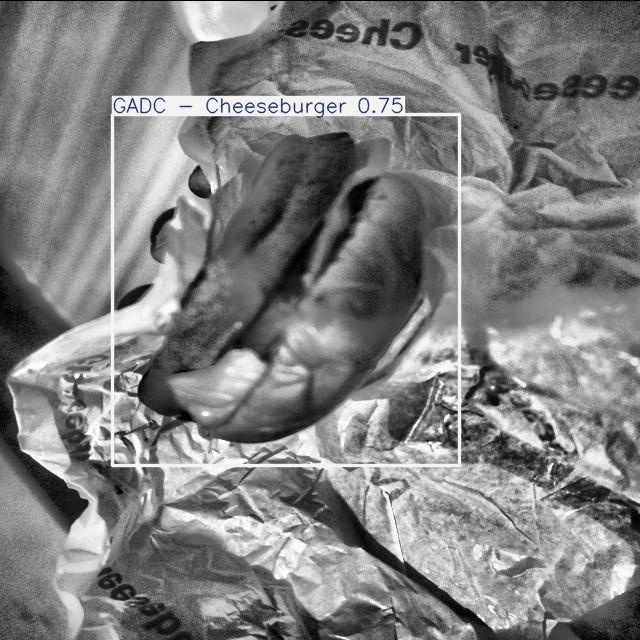

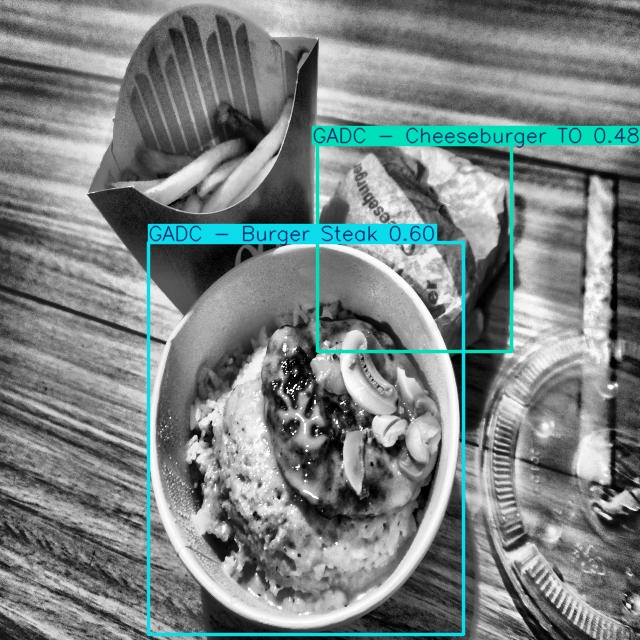

In [31]:
import glob
import os
from IPython.display import Image as IPyImage, display

latest_folder = max(glob.glob(f'{HOME}/runs/detect/predict*/'), key=os.path.getmtime)
for img in glob.glob(f'{latest_folder}/*.jpg')[:3]:
    display(IPyImage(filename=img, width=600))
    print("\n")

## Deploy model on Roboflow

Once you have finished training your YOLOv11 model, you’ll have a set of trained weights ready for use. These weights will be in the `/runs/detect/train/weights/best.pt` folder of your project. You can upload your model weights to Roboflow Deploy to use your trained weights on our infinitely scalable infrastructure.

The `.deploy()` function in the [Roboflow pip package](https://docs.roboflow.com/python) now supports uploading YOLOv11 weights.

In [33]:
project.version(dataset.version).deploy(model_type="yolov11", model_path=f"{HOME}/runs/detect/train3/")

View the status of your deployment at: https://app.roboflow.com/joshs-data-science-projects/food-detection-rxmdl-boyoj/5
Share your model with the world at: https://universe.roboflow.com/joshs-data-science-projects/food-detection-rxmdl-boyoj/model/5


In [36]:
!pip install inference

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.7/105.7 kB 5.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 9.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.4/99.4 kB 10.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 37.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.9/75.9 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 76.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 85.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.4/243.4 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.0/64.0 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 68.5 MB/s eta 0:00

In [11]:
# Import necessary libraries
from google.colab import userdata
from roboflow import Roboflow

# Define the project and dataset information
project = {
    'id': 'food-detection-rxmdl-boyoj',  # Replace with your project ID
}

dataset = {
    'version': '5',  # Replace with your dataset version number
    'location': '/content/datasets/Food-Detection-5'  # This is where your dataset is located after downloading
}

# Initialize the Roboflow client
ROBOFLOW_API_KEY = 'LUyk335leXSb5LPcrdzZ'  # Your API key
rf = Roboflow(api_key=ROBOFLOW_API_KEY)

# Get the model from Roboflow using the model_id
model = rf.workspace("joshs-data-science-projects").project(project['id']).version(dataset['version']).model


loading Roboflow workspace...
loading Roboflow project...


loading Roboflow workspace...
loading Roboflow project...
Running inference on DSC04090_JPG.rf.e1b83b44a61a3ccbd9338c850a11f3c4.jpg


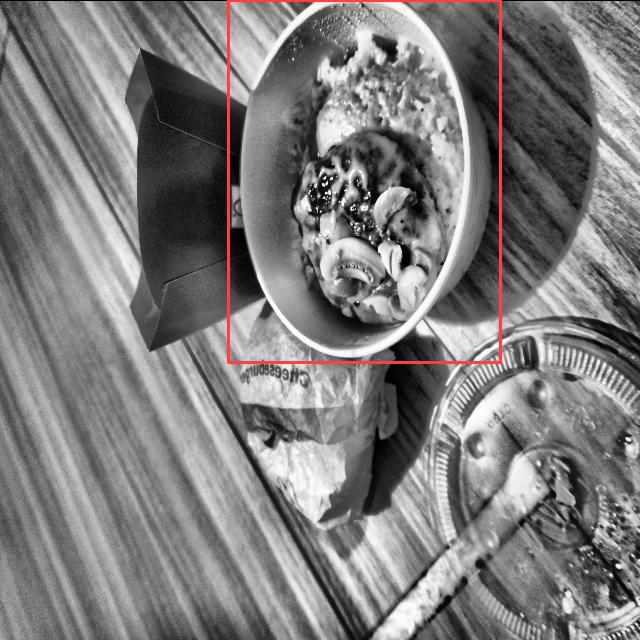

Running inference on 1291dbed-25f4-467e-bed5-cb314571be82-1-_jpeg.rf.b1439bc73e331e2441846ca502876ccb.jpg


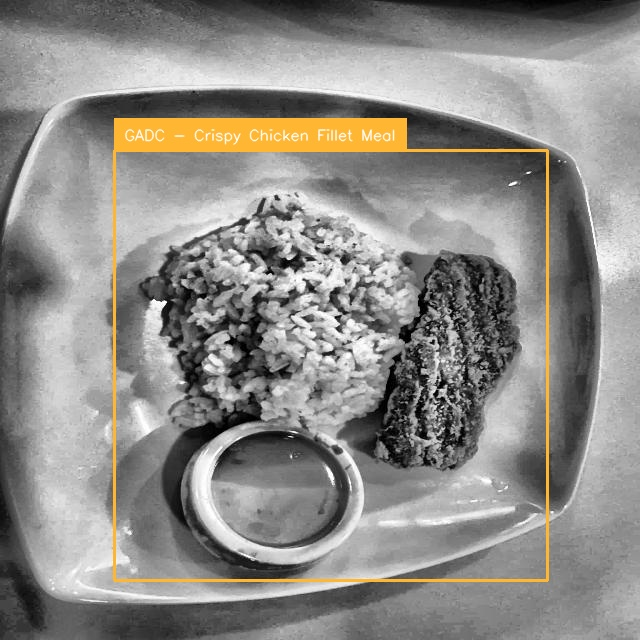

Running inference on DSC04319_JPG.rf.1461122465a4f0c216b18bb7f4e9c027.jpg


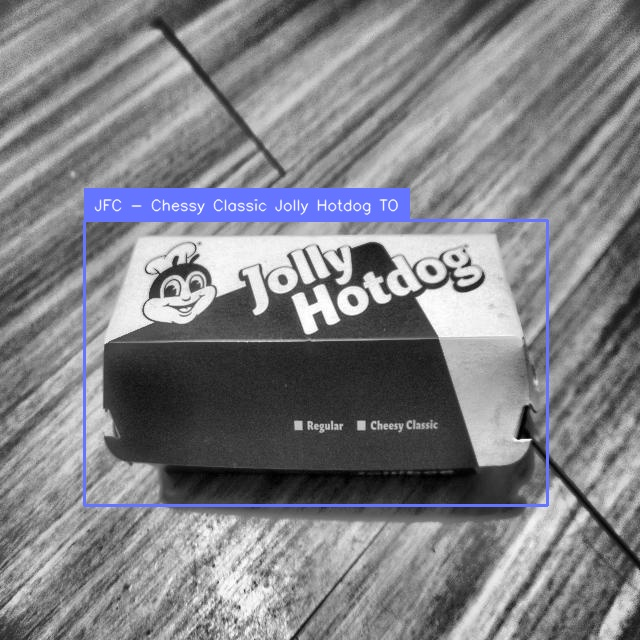

Running inference on DSC05082_JPG.rf.515902cc123a1b9232390048ff7b0927.jpg


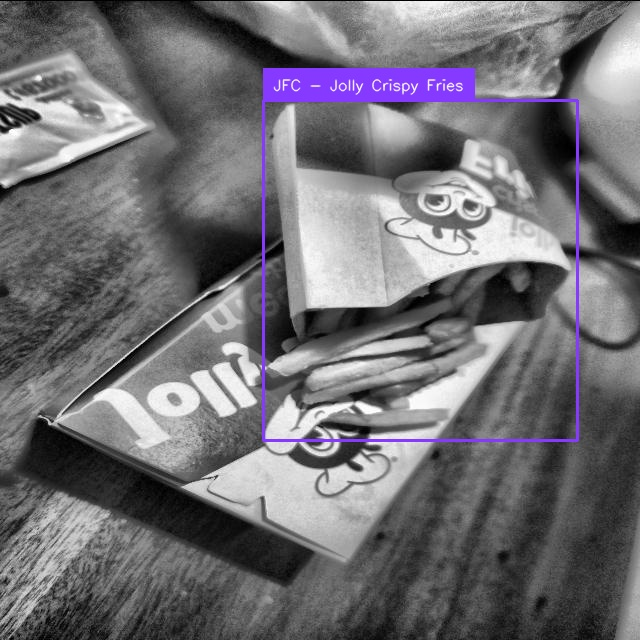

In [15]:
import os, random, cv2
import supervision as sv
import IPython
from roboflow import Roboflow

# Define the project and dataset information
project = {
    'id': 'food-detection-rxmdl-boyoj',  # Replace with your project ID
}

dataset = {
    'version': '5',  # Replace with your dataset version number
    'location': '/content/datasets/Food-Detection-5'  # This is where your dataset is located after downloading
}

# Initialize the Roboflow client
ROBOFLOW_API_KEY = 'LUyk335leXSb5LPcrdzZ'  # Your API key
rf = Roboflow(api_key=ROBOFLOW_API_KEY)

# Get the model from Roboflow using the model_id
model = rf.workspace("joshs-data-science-projects").project(project['id']).version(dataset['version']).model

# Location of test set images
test_set_loc = dataset['location'] + "/test/images/"
test_images = os.listdir(test_set_loc)

# Run inference on 4 random test images, or fewer if fewer images are available
for img_name in random.sample(test_images, min(4, len(test_images))):
    print("Running inference on " + img_name)

    # Load image
    image = cv2.imread(os.path.join(test_set_loc, img_name))

    # Perform inference using the correct 'predict' method
    results = model.predict(image, confidence=0.4, overlap=30).json()

    # Convert the results to detections
    detections = sv.Detections.from_inference(results)

    # Annotate boxes and labels
    box_annotator = sv.BoxAnnotator()
    label_annotator = sv.LabelAnnotator()
    annotated_image = box_annotator.annotate(scene=image, detections=detections)
    annotated_image = label_annotator.annotate(scene=annotated_image, detections=detections)

    # Display annotated image
    _, ret = cv2.imencode('.jpg', annotated_image)
    i = IPython.display.Image(data=ret)
    IPython.display.display(i)


## Create TF Lite version

In [17]:
pip install onnx onnx-tf tensorflow


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.1/226.1 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611.8/611.8 kB 27.6 MB/s eta 0:00:00
  Attempting uninstall: typeguard
    Found existing installation: typeguard 4.4.2
    Uninstalling typeguard-4.4.2:
      Successfully uninstalled typeguard-4.4.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
inflect 7.5.0 requires typeguard>=4.0.1, but you have typeguard 2.13.3 which is incompatible.


In [24]:
# Clean install with compatible versions
!pip uninstall -y tensorflow keras
!pip install tensorflow==2.10 keras==2.10 onnx onnx-tf

ERROR: Could not find a version that satisfies the requirement tensorflow==2.10 (from versions: 2.12.0rc0, 2.12.0rc1, 2.12.0, 2.12.1, 2.13.0rc0, 2.13.0rc1, 2.13.0rc2, 2.13.0, 2.13.1, 2.14.0rc0, 2.14.0rc1, 2.14.0, 2.14.1, 2.15.0rc0, 2.15.0rc1, 2.15.0, 2.15.0.post1, 2.15.1, 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0)
ERROR: No matching distribution found for tensorflow==2.10


In [25]:
# Install required packages
!pip install onnx onnx2tf

In [26]:
# Step 1: Export the YOLOv11 model to ONNX
from ultralytics import YOLO
model = YOLO('yolo11n.pt')
model.export(format='onnx')  # creates 'yolo11n.onnx'

Ultralytics 8.3.40 🚀 Python-3.11.12 torch-2.6.0+cu124 CPU (Intel Xeon 2.00GHz)
YOLO11n summary (fused): 238 layers, 2,616,248 parameters, 0 gradients, 6.5 GFLOPs

PyTorch: starting from 'yolo11n.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 84, 8400) (5.4 MB)

ONNX: starting export with onnx 1.17.0 opset 19...
ONNX: slimming with onnxslim 0.1.50...
ONNX: export success ✅ 1.3s, saved as 'yolo11n.onnx' (10.2 MB)

Export complete (1.8s)
Results saved to /content
Predict:         yolo predict task=detect model=yolo11n.onnx imgsz=640  
Validate:        yolo val task=detect model=yolo11n.onnx imgsz=640 data=/usr/src/ultralytics/ultralytics/cfg/datasets/coco.yaml  
Visualize:       https://netron.app


'yolo11n.onnx'

In [28]:
!pip install tensorflow==2.13.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 524.2/524.2 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 71.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 109.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 114.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 440.8/440.8 kB 37.9 MB/s eta 0:00:00
  Attempting uninstall: typing-extensions
    Found existing installation: typing_extensions 4.12.2
    Uninstalling typing_extensions-4.12.2:
      Successfully uninstalled typing_extensions-4.12.2
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: gast
    Found existing installation: gast 0.6.0
    Uninstalling gast-0.6.0:
      Successfully uninstalled gast-0.6.0
  Attempting uninstall: google-auth-oauthlib
    Found existing installation: google-auth-oauthlib 1.2.2
    Unin

In [2]:
!pip install --upgrade numpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 96.2 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.24.3
    Uninstalling numpy-1.24.3:
      Successfully uninstalled numpy-1.24.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.13.0 requires numpy<=1.24.3,>=1.22, but you have numpy 2.2.5 which is incompatible.
inference 0.48.0 requires typing_extensions<=4.12.2,>=4.8.0, but you have typing-extensions 4.5.0 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.2.3 which is incompatible.
nibabel 5.3.2 requires typing-extensions>=4.6; python_version < "3.13", but you have typing-extensions 4.5.0 which is incompatible.
tensorflow-text 2.18.1 requires tensorflow<2.19,>=2.18.0, but you have te

In [4]:
pip install "numpy<2"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 94.1 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.5
    Uninstalling numpy-2.2.5:
      Successfully uninstalled numpy-2.2.5
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.13.0 requires numpy<=1.24.3,>=1.22, but you have numpy 1.26.4 which is incompatible.
inference 0.48.0 requires numpy<2.3.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.
inference 0.48.0 requires typing_extensions<=4.12.2,>=4.8.0, but you have typing-extensions 4.5.0 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.2.3 which is incompatible.
nibabel 5.3.2 requires typing-extensions>=4.6; python_version < "3.13", but you have typing-extensions 4.5.0 wh

In [8]:
# Step 2: Convert ONNX to TFLite using onnx2tf
!onnx2tf -i yolo11n.onnx


Model optimizing started ============================================================
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/onnx2tf/onnx2tf.py", line 631, in convert
    result = subprocess.check_output(
             ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.11/subprocess.py", line 466, in check_output
    return run(*popenargs, stdout=PIPE, timeout=timeout, check=True,
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.11/subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.11/subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "/usr/lib/python3.11/subprocess.py", line 1955, in _execute_child
    raise child_exception_type(errno_num, err_msg, err_filename)
FileNotFoundError: [Errno 2] No such file or directory: 'onnxsim'


Automatic generatio

## 🏆 Congratulations

### Learning Resources

Roboflow has produced many resources that you may find interesting as you advance your knowledge of computer vision:

- [Roboflow Notebooks](https://github.com/roboflow/notebooks): A repository of over 20 notebooks that walk through how to train custom models with a range of model types, from YOLOv7 to SegFormer.
- [Roboflow YouTube](https://www.youtube.com/c/Roboflow): Our library of videos featuring deep dives into the latest in computer vision, detailed tutorials that accompany our notebooks, and more.
- [Roboflow Discuss](https://discuss.roboflow.com/): Have a question about how to do something on Roboflow? Ask your question on our discussion forum.
- [Roboflow Models](https://roboflow.com): Learn about state-of-the-art models and their performance. Find links and tutorials to guide your learning.

### Convert data formats

Roboflow provides free utilities to convert data between dozens of popular computer vision formats. Check out [Roboflow Formats](https://roboflow.com/formats) to find tutorials on how to convert data between formats in a few clicks.

### Connect computer vision to your project logic

[Roboflow Templates](https://roboflow.com/templates) is a public gallery of code snippets that you can use to connect computer vision to your project logic. Code snippets range from sending emails after inference to measuring object distance between detections.